# Titanic 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings("ignore")

## EDA

In [3]:
df=pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [9]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [10]:
df["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [11]:
df["SibSp"].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [12]:
df["Parch"].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

In [13]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [14]:
df=df.drop(columns=["PassengerId","Name"])

## Feature Distribution

Text(0.5, 1.0, 'Survival rate')

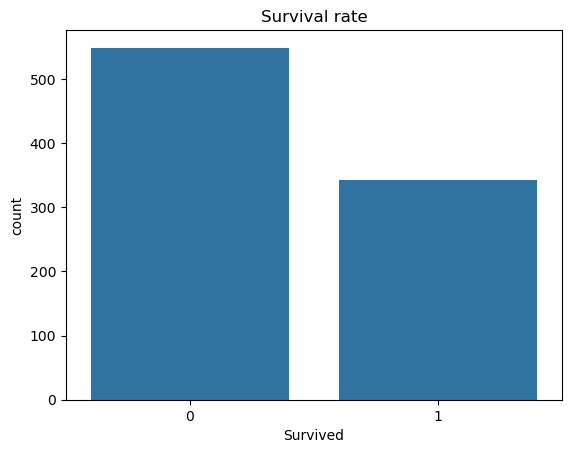

In [15]:
sns.countplot(x=df["Survived"])
plt.title("Survival rate")

Text(0.5, 1.0, 'Survival rate by gender')

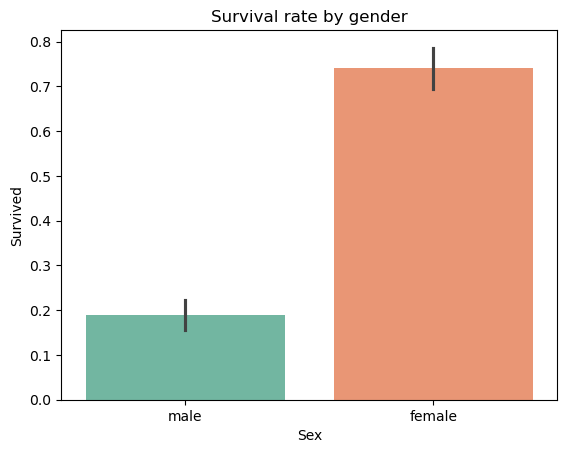

In [16]:
sns.barplot(x=df["Sex"],y=df["Survived"],palette="Set2")
plt.title("Survival rate by gender")

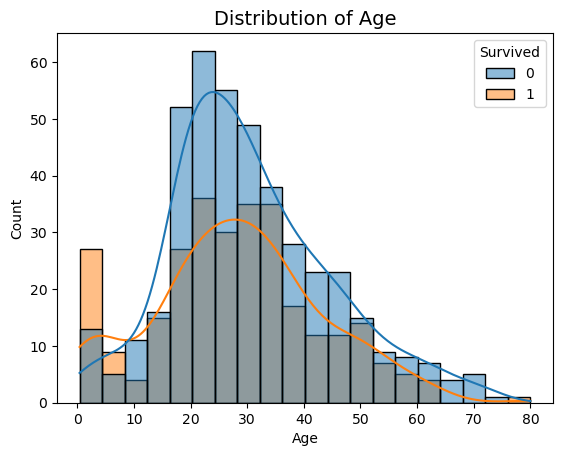

In [17]:
sns.histplot(
        data=df, 
        x=df["Age"], 
        hue=df["Survived"],
        kde=True,
    )
    
plt.title("Distribution of Age", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


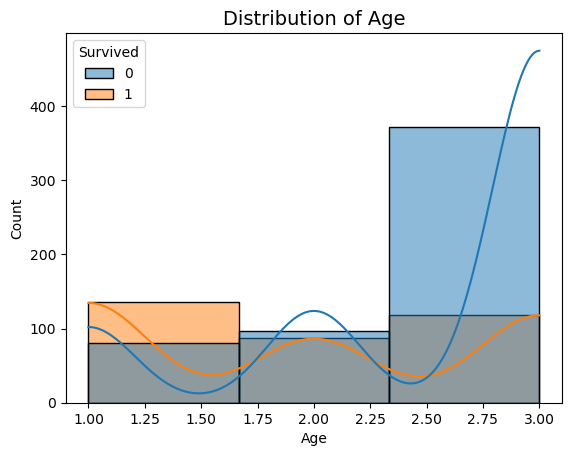

In [18]:
sns.histplot(
        data=df, 
        x=df["Pclass"], 
        hue=df["Survived"],
        bins=3,
        kde=True,
    )
    
plt.title("Distribution of Age", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


Text(0.5, 1.0, 'Corelation matrix of titanic features')

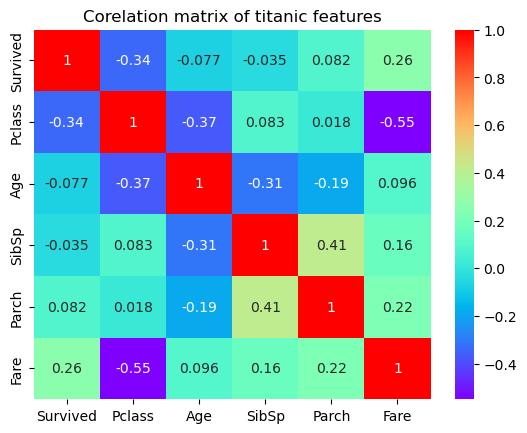

In [19]:
numeric_df=df.select_dtypes(include="number")

sns.heatmap(numeric_df.corr(),annot=True,cmap="rainbow")
plt.title("Corelation matrix of titanic features")

Text(0.5, 1.0, 'Scatter plot of Fare')

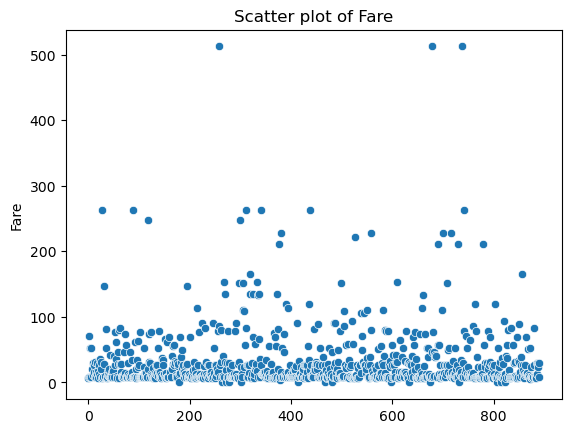

In [20]:
sns.scatterplot(df["Fare"])
plt.title("Scatter plot of Fare")

In [21]:
df.isna().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [22]:
df["Age"]=df["Age"].fillna(df["Age"].mean())

In [23]:
df=df.dropna(subset="Embarked")

In [24]:
df["Cabin"].value_counts()

Cabin
C23 C25 C27    4
G6             4
B96 B98        4
F33            3
E101           3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 146, dtype: int64

## Encoding

In [25]:
df["Sex"]=df["Sex"].map({"male":0,"female":1})
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,0,22.000000,1,0,A/5 21171,7.2500,NaN,S
1,1,1,1,38.000000,1,0,PC 17599,71.2833,C85,C
2,1,3,1,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,1,35.000000,1,0,113803,53.1000,C123,S
4,0,3,0,35.000000,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...
886,0,2,0,27.000000,0,0,211536,13.0000,NaN,S
887,1,1,1,19.000000,0,0,112053,30.0000,B42,S
888,0,3,1,29.699118,1,2,W./C. 6607,23.4500,NaN,S
889,1,1,0,26.000000,0,0,111369,30.0000,C148,C


In [26]:
df=pd.get_dummies(df,columns=['Embarked'],dtype=int,drop_first=True)

## FeaturE Engineering

In [27]:
df["Family_Size"]=df["SibSp"]+df["Parch"]+1
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_Q,Embarked_S,Family_Size
0,0,3,0,22.0,1,0,A/5 21171,7.2500,NaN,0,1,2
1,1,1,1,38.0,1,0,PC 17599,71.2833,C85,0,0,2
2,1,3,1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,1,1
3,1,1,1,35.0,1,0,113803,53.1000,C123,0,1,2
4,0,3,0,35.0,0,0,373450,8.0500,NaN,0,1,1


In [28]:
df["is_alone"]=0
df.loc[df["Family_Size"]==1,"is_alone"]=1
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_Q,Embarked_S,Family_Size,is_alone
0,0,3,0,22.0,1,0,A/5 21171,7.2500,NaN,0,1,2,0
1,1,1,1,38.0,1,0,PC 17599,71.2833,C85,0,0,2,0
2,1,3,1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,1,1,1
3,1,1,1,35.0,1,0,113803,53.1000,C123,0,1,2,0
4,0,3,0,35.0,0,0,373450,8.0500,NaN,0,1,1,1


In [29]:
df["has_Cabin"]=df["Cabin"].notnull().astype(int)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_Q,Embarked_S,Family_Size,is_alone,has_Cabin
0,0,3,0,22.0,1,0,A/5 21171,7.2500,NaN,0,1,2,0,0
1,1,1,1,38.0,1,0,PC 17599,71.2833,C85,0,0,2,0,1
2,1,3,1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,1,1,1,0
3,1,1,1,35.0,1,0,113803,53.1000,C123,0,1,2,0,1
4,0,3,0,35.0,0,0,373450,8.0500,NaN,0,1,1,1,0


In [30]:
df=df.drop(columns=["Ticket","SibSp","Parch","Cabin"])
df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked_Q,Embarked_S,Family_Size,is_alone,has_Cabin
0,0,3,0,22.0,7.2500,0,1,2,0,0
1,1,1,1,38.0,71.2833,0,0,2,0,1
2,1,3,1,26.0,7.9250,0,1,1,1,0
3,1,1,1,35.0,53.1000,0,1,2,0,1
4,0,3,0,35.0,8.0500,0,1,1,1,0


In [31]:
df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked_Q,Embarked_S,Family_Size,is_alone,has_Cabin
0,0,3,0,22.0,7.2500,0,1,2,0,0
1,1,1,1,38.0,71.2833,0,0,2,0,1
2,1,3,1,26.0,7.9250,0,1,1,1,0
3,1,1,1,35.0,53.1000,0,1,2,0,1
4,0,3,0,35.0,8.0500,0,1,1,1,0


## Features Scaling

In [32]:
from sklearn.preprocessing import StandardScaler

feature_col=["Age","Family_Size","Fare"]
scalar=StandardScaler()

df[feature_col]=scalar.fit_transform(df[feature_col])

df.head()



,Survived,Pclass,Sex,Age,Fare,Embarked_Q,Embarked_S,Family_Size,is_alone,has_Cabin
0,0,3,0,-0.590495,-0.500240,0,1,0.057853,0,0
1,1,1,1,0.643971,0.788947,0,0,0.057853,0,1
2,1,3,1,-0.281878,-0.486650,0,1,-0.561804,1,0
3,1,1,1,0.412509,0.422861,0,1,0.057853,0,1
4,0,3,0,0.412509,-0.484133,0,1,-0.561804,1,0


## Train Test Split

In [33]:
X=df[['Pclass', 'Sex', 'Age', 'Fare', 'Embarked_Q', 'Embarked_S', 'Family_Size', 'is_alone', 'has_Cabin']]

y=df["Survived"]

In [34]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)


## Model Selection

In [35]:
from sklearn.linear_model import LogisticRegression

model=LogisticRegression()

model.fit(X_train,y_train)

LogisticRegression()

In [36]:
y_pred=model.predict(X_test)
y_pred

array([0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 1])

In [37]:
y_test

281    0
435    1
39     1
418    0
585    1
      ..
433    0
807    0
25     1
85     1
10     1
Name: Survived, Length: 178, dtype: int64

## Model Evaluation

In [38]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

confusion_matrix(y_test,y_pred)

array([[89, 20],
       [14, 55]])

In [39]:
accuracy_score(y_test,y_pred)

0.8089887640449438

In [40]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.86      0.82      0.84       109
           1       0.73      0.80      0.76        69

    accuracy                           0.81       178
   macro avg       0.80      0.81      0.80       178
weighted avg       0.81      0.81      0.81       178



## Try KNN Model

In [41]:
from sklearn.neighbors import KNeighborsClassifier

knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train,y_train)



KNeighborsClassifier()

In [43]:
y_pred_knn=knn_model.predict(X_test)

In [44]:
accuracy_score(y_test,y_pred_knn)

0.7808988764044944

In [45]:
confusion_matrix(y_test,y_pred_knn)

array([[87, 22],
       [17, 52]])

In [46]:
print(classification_report(y_test,y_pred_knn))

              precision    recall  f1-score   support

           0       0.84      0.80      0.82       109
           1       0.70      0.75      0.73        69

    accuracy                           0.78       178
   macro avg       0.77      0.78      0.77       178
weighted avg       0.78      0.78      0.78       178

